# Red Noise in Massive Stars

In [287]:
%matplotlib inline
#plt.style.use('/Users/mcantiello/.matplotlib/mesa.mplstyle')


import matplotlib.pyplot as plt
import mesa_reader as mr
import numpy as np
from pylab import *
from math import log10, pi
from matplotlib import rc
#rc('mathtext', default='regular')
import matplotlib as mpl
import matplotlib.tri as tri

import matplotlib.transforms as mtransforms
from matplotlib.ticker import MaxNLocator
from scipy import interpolate
from scipy.interpolate import griddata


from numpy import loadtxt
import pandas as pd 
from matplotlib.patches import Rectangle
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
import matplotlib.gridspec as gridspec

    
from Constants import Constants
c=Constants() 

# Define some colors
BLACK      = (0.00,0.00,0.00)
ORANGE     = (0.90,0.60,0.00)
SKY_BLUE   = (0.35,0.70,0.90)
BLUE_GREEN = (0.00,0.60,0.50)
YELLOW     = (0.95,0.90,0.25)
BLUE       = (0.00,0.45,0.70)
VERMILLION = (0.80,0.40,0.00)
RED_PURPLE = (0.80,0.60,0.70)

Constants defined...


In [288]:
####################################################
# Plt Options from Perna, Lazzati & Cantiello 2017 #
####################################################
plt.rcParams['figure.figsize'] = (6,5)
plt.rcParams['font.family'] = ['Times New Roman']
#plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['mathtext.fontset'] = 'dejavusans'
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['mathtext.rm'] = 'serif'
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['xtick.labelsize'] = 20
plt.rcParams['ytick.labelsize'] = 20
plt.rcParams['axes.titlepad'] = 20 
plt.rcParams['legend.frameon'] = False
plt.rcParams['legend.fontsize'] = 14
plt.rcParams['font.size'] = 16
plt.rcParams['legend.borderpad'] = 0.2
#plt.rc('legend', borderpad=0.2, markerscale=15., fancybox=False)
plt.rc('legend', borderpad=0.2, markerscale=1., fancybox=False)
plt.rcParams['legend.labelspacing'] = 0.5
plt.rcParams['legend.handletextpad'] = 0.5
plt.rcParams['legend.handlelength'] = 1
plt.rcParams["legend.framealpha"] = 1.0
####################################################

In [289]:
rsun=6.9598e10
msun=1.9892e33
lsun=3.8418e33
tsun = 5777
G=6.67428e-8 

In [290]:
def find_zams(logl,loglh,model):
    zams=1
    while (loglh[zams] < 1.0*logl[zams]): 
     zams=zams+1
    return zams; 

def find_h(dh,center_h1,model):
    zams=1
    while (center_h1[zams] > (center_h1[1] - dh)): 
     zams=zams+1
    return zams; 
    
def find_tams(center_h1,model):
    tams=1
    while (center_h1[tams] > 0.05): 
     tams=tams+1
    return tams;    

def find_max(a,b,c,d):
    z= [0] * len(a)
    for i in range(0, len(a)):
      z[i]=max(a[i],b[i],c[i],d[i])   
    return z;

def binary(z):  
    for i in range(0, len(z)):
      if z[i] > 0:
         z[i] = 1
      else: 
         z[i] = 0
    return z;

def pbeta(p,b):    # Plasma Beta
    beta= 8*3.1415*p/(b**2.0)
    return beta;

def rossby(vcon,vroteq,hp,req): # Rossby number, defined as Prot/Pcon
    ross =(3.14*req/hp)*(vcon/veq)
    return ross; 
def beq(vcon,rho): # Calculate equipartition Bfield
    b=vcon*(4*3.14*rho)**0.5
    return b;
def char_freq(vcon,hp,req): # Rossby number, defined as Prot/Pcon
    ross =(3.14*req/hp)*(vcon/veq)
    return ross; 

## Some useful definitions for working with IGWs  
$k_r = \frac{\sqrt{\ell(\ell +1)} N}{\omega \,r} $

$k_h = \frac{\sqrt{\ell(\ell +1)}}{r} $

$k_r^2 = k_h^2 \, \frac{N^2}{\omega^2}$

$v_{g,r} = \frac{r \omega^2}{N \sqrt{\ell(\ell +1)}}$

$\xi_r = \Big[ \frac{2 F_{IGW} \sqrt{\ell(\ell+1)}}{r \rho \omega^2 \sqrt{N^2-\omega^2}} \Big]^{1/2}$


In [322]:
def k_h(ell,radius):    # Calculate horizontal wavenumber of  IGWs
    kh = ((ell * (ell+1))**0.5)/radius
    return kh;

def k_r(ell,brunt,omega,radius):    # Calculate radial wavenumber of  IGWs
    a = brunt * (ell * ( ell + 1))**0.5
    b = (omega * radius)
    kr = np.divide(a, b, out=np.zeros_like(a), where=b!=0)
    return kr;

def vg_r(ell,brunt,omega,radius):    # Calculate horizontal wavenumber of  IGWs
    a = radius * omega**2.0
    b = brunt * (ell * (ell+1))**0.5  
    kh = np.divide(a, b, out=np.zeros_like(a), where=b!=0)
    return vg_r;

def xi_r(ell,brunt,omega,radius, rho, figw): # Calculate radial displacement from IGWs with flux Figw
    xir = 2.0*figw*(ell *( ell + 1))**0.5
    xir = xir / (radius * rho * omega**2.0)
    xir = xir / (brunt**2.0 - omega**2.0)**0.5
    xir = xir**0.5
    return xir;

def lamb_ell(lamb1,ell):         # Return Lamb_ell Given Lamb_1
    lambell=lamb1*(ell*(ell+1)/2)**0.5
    return lambell;

#def xi_r(ell,brunt,omega,radius, rho, figw): # Calculate radial displacement from IGWs with flux Figw
#    xir = 2.0*figw*(ell *( ell + 1))**0.5
#    xir = xir / (radius * rho * omega**2.0)
#    xir = xir / brunt
#    xir = xir**0.5
#    return xir;


## Frequencies Definition:
First let's define the angular frequency $\omega$.
The characteristic angular frequency of the waves is the angular convective turnover frequency $\omega_c$ near the radiative–convective interface.

$\omega \equiv \frac{v_c}{\lambda}$

where $\lambda$ is the mixing length and $v_c$ is the convective velocity. This is the definition we used in Fuller et al. 2014.

In Fuller et al. 2015 we used a slightly different definition:

$\omega \equiv \frac{\pi v_c}{\lambda} = \frac{\pi v_c}{\alpha H_P }$.

In Bowmnan et al. 2020 a characteristic frequency is defined such as:

$\nu_{\rm char} \equiv \frac{1}{2\pi\tau}$ 

where $\tau$ is a characteristic timescale. If we take $\tau$ to be the turnover timescale 

$\tau_c \equiv \frac{2 \alpha  H_P}{v_c}$

Then we can write 

$\omega_c = 2\pi \nu_{\rm char} $ (Using F14 definition), or $\omega_c = 2\pi^2 \nu_{\rm char} $ (Using F15 definition).
Let's stick to F14.

And $\nu_c \equiv \omega_c / 2\pi $ (e.g. Shiode et al. 2013)


In [323]:
DIR = '/Users/mcantiello/Dropbox (Personal)/work/red_noise/Z0.02_CORE/'
mods = [5.0, 5.2, 5.4 ,5.6 ,5.8, 6.0, 7.0,8.0,9.0,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,30,40,50,60,80,100,120]
hrdlines = [5.0,6.0,7.0,9.0,11,13,15,20,25,30,40,60,80,120]
figures = '/Users/mcantiello/Dropbox (Personal)/work/red_noise/figures/'

## Identify and Take values in the Core

0.11071415288847075


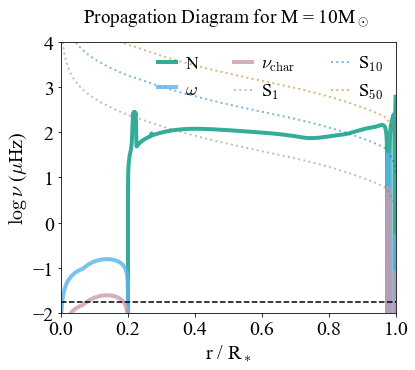

In [342]:
mesa=mr.MesaData(DIR+'10/LOGS/profile10.data')
dir(mesa)
mesa.bulk_names

pi2= 2*3.1415

# Units of brunt in MESA? 
#log_brunt_nu(k) = safe_log10_cr((1d6/(2*pi))*sqrt(max(0d0,s% brunt_N2(k))))
#lamb_S2 ! for l=1: S = 2*(csound/r)^2
# lamb_S ! for l=1: S = sqrt(2)*csound/r
muhz=1e-6 #conversion factor from muhz to hz

brunt=(1e6/pi2)*10**mesa.log_brunt_N
lamb1=(1e6/pi2)*mesa.lamb_S


lamb10=lamb_ell(lamb1,10)
lamb50=lamb_ell(lamb1,50)
lamb100=lamb_ell(lamb1,100)
lamb300=lamb_ell(lamb1,300)

plt.plot(mesa.radius/mesa.radius[1],np.log10(brunt),linewidth=4, alpha=0.8,label = r'N',color=BLUE_GREEN)

## Calculate Omega (nu_char)
# Extract Omega:
# Calculate turnover timescale
vc=10**mesa.log_conv_vel
alpha_mlt = 1.6
hp=mesa.pressure_scale_height 
turnover=2*alpha_mlt*hp*rsun/vc     # 2 Lambda / vc

nu_char=1.0/(2*3.1415*turnover)     # Definition in Bowman et al. 2020

omega=vc/(2*alpha_mlt*hp*rsun)      # definition from Fuller et al. 2014 (there is a 2 here)

## Identify values in the core
i=len(vc)-1
while (vc[i] > 0.00001):
    i=i-1
omega_core=np.mean(omega[i:])   
i_core = i
print(omega_core/muhz)    
##

plt.plot(mesa.radius/mesa.radius[1],np.log10(omega/muhz),linewidth=4, alpha=0.8,label = r'$\omega$',color=SKY_BLUE)
plt.plot(mesa.radius/mesa.radius[1],np.log10(nu_char/muhz),linewidth=4, alpha=0.8,label = r'$\nu_{\rm char}$',color=RED_PURPLE)

plt.plot(mesa.radius/mesa.radius[1],np.log10(lamb1),linewidth=2, ls=':', alpha=0.5,label = r'S$_1$',color='gray')
plt.plot(mesa.radius/mesa.radius[1],np.log10(lamb10),linewidth=2, ls=':',alpha=0.5,label = r'S$_{10}$',color=BLUE)
plt.plot(mesa.radius/mesa.radius[1],np.log10(lamb50),linewidth=2, ls=':',alpha=0.5,label = r'S$_{50}$',color=VERMILLION)
#plt.plot(mesa.radius/mesa.radius[1],np.log10(lamb30),linewidth=2, alpha=0.8,label = r'  S$_{30}$')
#plt.plot(mesa.radius/mesa.radius[1],np.log10(lamb300),linewidth=2, alpha=0.8,label = r'S$_{\ell = 300}$')
plt.axhline(y=np.log10(omega_core/(pi2*muhz)), color=BLACK, linestyle='--')

legend = plt.legend(loc='upper right',fontsize=18,ncol=3)

plt.axis([0.0,1, -2,4])
plt.xlabel(r'r / R$_*$')
plt.ylabel(r'$\log\, \nu$ ($\mu$Hz)')
plt.title(r'Propagation Diagram for M = 10M$_\odot$ ') #X$_c$=0.68
plt.savefig(figures+"Propagation10Msun_zoom.pdf",bbox_inches='tight')


[2.24135771e-04 2.24074593e-04 2.23800848e-04 ... 1.00000000e-99
 1.00000000e-99 1.00000000e-99]
10804508284.09913
[3.27505017e+01 3.27504213e+01 3.27502432e+01 ... 1.65419534e-02
 1.31292771e-02 1.04206765e-02]


/Users/mcantiello/anaconda/lib/python3.5/site-packages/ipykernel/__main__.py:12: RuntimeWarning: invalid value encountered in sqrt
/Users/mcantiello/anaconda/lib/python3.5/site-packages/ipykernel/__main__.py:20: RuntimeWarning: invalid value encountered in sqrt


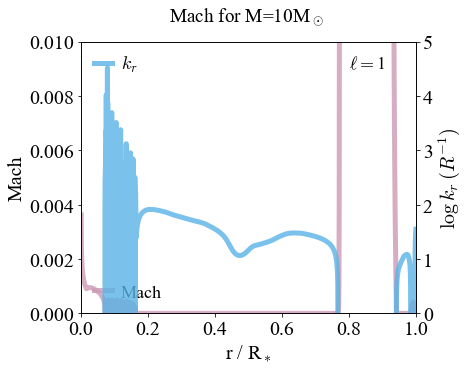

In [351]:
fig, ax1 = plt.subplots()
ell=1


# Calculate F0

N=brunt*muhz*pi2
print(N)
rho=10**mesa.logRho
F0=0.5*rho*(rsun*mesa.radius)**3.0
F0=F0*omega_core**2.0
F0=F0*(N**2.0 - omega_c**2.0)**0.5
#F0=F0*N
F0_surf=F0[1] # Take surface value of F0 
print(F0[1])

# Calculate Total Stellar Flux

L=mesa.photosphere_L
R=mesa.photosphere_r
F=(L*lsun)/(4*pi*(R*rsun)**2.0)

# Calculate Convective Flux
vc=10**mesa.log_conv_vel
Fc=rho*vc**3.0

# Calculate IGW Flux
mach=mesa.conv_vel_div_csound
Figw=Fc*mach
Figw_core= np.mean(Figw[i_core:])  # Take an average of Figw in the FeCZ


R = mesa.radius
ax1.plot(R/R[1],mach,linewidth=5, color=RED_PURPLE,alpha=0.8,label = r'Mach')
ax1.set_ylabel(r'Mach')
ax1.set_xlabel(r'r / R$_*$')
ax1.set_xlim(0,1)
ax1.set_ylim(0,1)
legend1 = plt.legend(loc='lower left',fontsize=18,ncol=1)

ax2=ax1.twinx()
print(mesa.radius)
# Calculate radial wavenumber 
kr = k_r(ell,brunt*muhz,omega_core/pi2,R)
kh = k_h(ell,R)

ax2.plot(R/R[1],np.log10(kr),linewidth=5, color=SKY_BLUE,alpha=0.8,label = r'$k_r$')
#ax2.plot(R/R[1],kh,linewidth=3, color=ORANGE,alpha=0.8,label = r'$k_h$')
#ax2.plot(mesa.radius/mesa.radius[1],np.log10((Figw/F)**0.5),linewidth=5, color=BLUE_GREEN,alpha=0.8,label = r'$\sqrt{F_{IGW}/F_{*}}$')


xir= xi_r(ell,brunt*muhz,omega_core/pi2,R*rsun, rho, Figw_fecz)

#ax2.plot(mesa.radius/mesa.radius[1],np.log10(kr*xir),linewidth=5, color=BLUE_GREEN,alpha=0.8,label = r'$\xi_r \, k_r$')
#ax2.plot(R/R[1],xir/(R*rsun),linewidth=5, color=BLUE_GREEN,alpha=0.8,label = r'$\xi_r/ R $')
#ax2.plot(R/R[1],kr*xir/(R*rsun),linewidth=3, color=BLACK,alpha=0.5,label = r'$\xi_r \, k_r$')
legend2 = plt.legend(loc='upper left',fontsize=18,ncol=1)

#ax2.set_xlim(0.75,1)
ax2.set_ylim(0,5)
ax1.set_ylim(0,0.01)
ax2.set_ylabel(r'$\log \, k_r \, (R^{-1})$')
ax2.annotate('$\ell = $'+str(ell),(0.8,4.5), fontsize=18)

#plt.ylabel(r'$\log \sqrt{F_{IGW}/F_0}$')
plt.title(r'Mach for M=10M$_\odot$ ') #X$_c$=0.68
plt.savefig(figures+"kr_mach_core_10Msun.pdf",bbox_inches='tight')


# 40 Msun

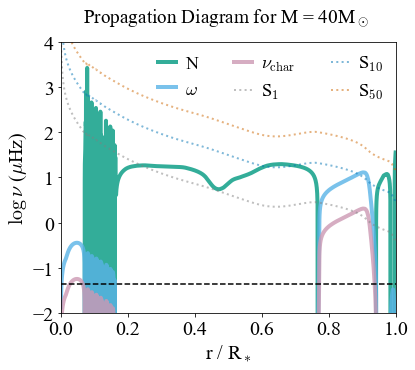

In [352]:
mesa=mr.MesaData(DIR+'40/LOGS/profile20.data')
dir(mesa)
mesa.bulk_names

#### Identify values in the core
# T_FeCZ  = (/ 100000,500000 /)  ! Rough T range for FeCZ Conv Region
# If temperature within the FeCZ range AND convective -> extract boundaries of FeCZ
vc=10**mesa.log_conv_vel

i=len(vc)-1
while (vc[i] > 0.00001):
    i=i-1
omega_core=np.mean(omega[i:])   
i_core = i

#####

# Units of brunt in MESA? 
#log_brunt_nu(k) = safe_log10_cr((1d6/(2*pi))*sqrt(max(0d0,s% brunt_N2(k))))
#lamb_S2 ! for l=1: S = 2*(csound/r)^2
# lamb_S ! for l=1: S = sqrt(2)*csound/r
muhz=1e-6 #conversion factor from muhz to hz

brunt=(1e6/pi2)*10**mesa.log_brunt_N
lamb1=(1e6/pi2)*mesa.lamb_S


lamb10=lamb_ell(lamb1,10)
lamb50=lamb_ell(lamb1,50)
lamb100=lamb_ell(lamb1,100)
lamb300=lamb_ell(lamb1,300)

plt.plot(mesa.radius/mesa.radius[1],np.log10(brunt),linewidth=4, alpha=0.8,label = r'N',color=BLUE_GREEN)

## Calculate Omega (nu_char)
# Extract Omega:
# Calculate turnover timescale
vc=10**mesa.log_conv_vel
alpha_mlt = 1.6
hp=mesa.pressure_scale_height 
turnover=2*alpha_mlt*hp*rsun/vc     # 2 Lambda / vc

nu_char=1.0/(pi2*turnover)     # Definition in Bowman et al. 2020

omega=1.0/turnover # vc/(2*alpha_mlt*hp*rsun)      # definition from Fuller et al. 2014 (there is a 2 here)

plt.plot(mesa.radius/mesa.radius[1],np.log10(omega/muhz),linewidth=4, alpha=0.8,label = r'$\omega$',color=SKY_BLUE)
plt.plot(mesa.radius/mesa.radius[1],np.log10(nu_char/muhz),linewidth=4, alpha=0.8,label = r'$\nu_{\rm char}$',color=RED_PURPLE)

plt.plot(mesa.radius/mesa.radius[1],np.log10(lamb1),linewidth=2, ls=':', alpha=0.5,label = r'S$_1$',color='gray')
plt.plot(mesa.radius/mesa.radius[1],np.log10(lamb10),linewidth=2, ls=':',alpha=0.5,label = r'S$_{10}$',color=BLUE)
plt.plot(mesa.radius/mesa.radius[1],np.log10(lamb50),linewidth=2, ls=':',alpha=0.5,label = r'S$_{50}$',color=VERMILLION)
#plt.plot(mesa.radius/mesa.radius[1],np.log10(lamb30),linewidth=2, alpha=0.8,label = r'  S$_{30}$')
#plt.plot(mesa.radius/mesa.radius[1],np.log10(lamb300),linewidth=2, alpha=0.8,label = r'S$_{\ell = 300}$')
plt.axhline(y=np.log10(omega_core/(pi2*muhz)), color=BLACK, linestyle='--')

legend = plt.legend(loc='upper right',fontsize=18,ncol=3)

plt.axis([0.0,1, -2,4])
plt.xlabel(r'r / R$_*$')
plt.ylabel(r'$\log\, \nu$ ($\mu$Hz)')
plt.title(r'Propagation Diagram for M = 40M$_\odot$ ') #X$_c$=0.68
plt.savefig(figures+"Propagation40Msun.pdf",bbox_inches='tight')


## Identify FeCZ and Take values in the CZ

In [353]:
temperature=mesa.temperature
minT=np.where(temperature > 9e4)
maxT=np.where(temperature < 1.6e5)
minT = minT[0][0]
maxT = maxT[-1][-1]

# T_FeCZ  = (/ 100000,500000 /)  ! Rough T range for FeCZ Conv Region
# If temperature within the FeCZ range AND convective -> extract boundaries of FeCZ
vc=10**mesa.log_conv_vel
temperature=mesa.temperature
mask1=np.where((temperature < 500000) & (temperature > 80000))
vc=10**mesa.log_conv_vel
vc1 = vc[mask1]
mask2=np.where((vc1 > 1e-3))
vc2 = vc1[mask2]

#omega_c=omega[mask1]
#omega_c=omega[mask2]
omega_c=np.mean(omega[minT:maxT])
print(omega_c)

print(np.mean(vc2)/1e5)
print(np.mean(vc[minT:maxT])/1e5)

3.6739052209416677e-06
16.47743187320444
10.203911898593924


## Propagation Diagram:  Upper Regions

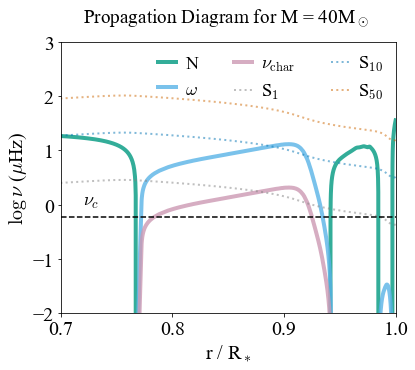

In [355]:

plt.plot(mesa.radius/mesa.radius[1],np.log10(brunt),linewidth=4, alpha=0.8,label = r'N',color=BLUE_GREEN)

nu_c=omega_c/(pi2)
#print(omega/muhz)
plt.plot(mesa.radius/mesa.radius[1],np.log10(omega/muhz),linewidth=4, alpha=0.8,label = r'$\omega$',color=SKY_BLUE)
plt.plot(mesa.radius/mesa.radius[1],np.log10(nu_char/muhz),linewidth=4, alpha=0.8,label = r'$\nu_{\rm char}$',color=RED_PURPLE)

plt.plot(mesa.radius/mesa.radius[1],np.log10(lamb1),linewidth=2, ls=':', alpha=0.5,label = r'S$_1$',color='gray')
plt.plot(mesa.radius/mesa.radius[1],np.log10(lamb10),linewidth=2, ls=':',alpha=0.5,label = r'S$_{10}$',color=BLUE)
plt.plot(mesa.radius/mesa.radius[1],np.log10(lamb50),linewidth=2, ls=':',alpha=0.5,label = r'S$_{50}$',color=VERMILLION)
#plt.plot(mesa.radius/mesa.radius[1],np.log10(lamb30),linewidth=2, alpha=0.8,label = r'  S$_{30}$')
#plt.plot(mesa.radius/mesa.radius[1],np.log10(lamb300),linewidth=2, alpha=0.8,label = r'S$_{\ell = 300}$')



plt.axhline(y=np.log10(nu_c/muhz), color=BLACK, linestyle='--')
plt.annotate(r'$\nu_c$',xy=(0.72,0),fontsize=18)

legend = plt.legend(loc='upper right',fontsize=18,ncol=3)

plt.axis([0.7,1, -2,3])
plt.xlabel(r'r / R$_*$')
plt.ylabel(r'$\log\, \nu$ ($\mu$Hz)')
plt.title(r'Propagation Diagram for M = 40M$_\odot$ ') #X$_c$=0.68
plt.savefig(figures+"Propagation_40Msun_zoom.pdf",bbox_inches='tight')


## Let's plot $F_0$

The flux of IGWs is defined as:

$F_{IGW} = \frac{1}{2} \rho \, |u|^2 u_{g,r}$, where the group velocity $u_{g,r} = \frac{\partial \omega}{\partial \kappa} $, resulting in 


$u_g,r = (\frac{\omega}{N})^2 \frac{\sqrt{N^2 - \omega^2}}{k_h}$

$|u|^2 = (N/\omega)^2 u_r^2$

$u_r = \omega \xi_r$

$F_{IGW} = \frac{1}{2} \rho \xi_r^2 \omega^2 \frac{\sqrt{N^2-\omega^2}}{k_h}$

$\xi_r = [ 2 F_{IGW} k_h/(\rho \omega^2 \sqrt{N^2-\omega^2}) ]^{1/2}$

$\xi_r/R = [ F_{IGW} k_h/(1/2 \rho R^2 \omega^2 \sqrt{N^2-\omega^2}) ]^{1/2}$

Since $k_h = \sqrt{\ell(\ell+1)}/R$

$\xi_r/R = [ F_{IGW} \sqrt{\ell(\ell+1)}/(1/2 \rho R^3 \omega^2 \sqrt{N^2-\omega^2}) ]^{1/2}$



Following e.g. Fuller et al. 2015 (appendix) we calculate the radial displacement from IGWs in the WKB limit (details above). 
This turns out to be 

$\frac{\delta r}{r} = \Big[\frac{F_{IGW} \sqrt{\ell(\ell+1)} }{1/2 \rho r^3 \omega^2 \sqrt{N^2 - \omega^2}}\Big]^{1/2}$

Using Dziembowski (1977) we can relate the radial displacement with luminosity fluctuations:

$|\delta m| = 1.087 \big[ b_{\ell} \frac{\delta F}{F_0} + (2 b_{\ell} - c_{\ell}) \frac{\delta r}{r} \big] $

Since the coefficient $b_{\ell} = c_{\ell}/\ell^2$, (and $c_{\ell, \lambda} \propto 1/\sqrt{\ell} $)  for high $\ell$ the temperature fluctuation term $\frac{\delta F}{F_0}$ drops, and we can then write:

$|\delta m| \approx 1.087 \sqrt{\frac{F_{IGW}}{1/2 \rho r^3 \omega^2 \sqrt{N^2 - \omega^2} }} = \sqrt{\frac{F_{IGW}}{F_0}}$ 


#################
The derivation in Aerts et al. is slightly different:

$|\delta m_{\lambda}| = 1.087 \sqrt{4\pi} \frac{\xi_r(R)}{R} c_{\ell m} P_\ell^m(\cos i) b_{\ell, \lambda} \times (A+B+C)$


$|\delta m_{\lambda}| = 1.087 \sqrt{4\pi} \frac{\xi_r(R)}{R} c_{\ell m} P_\ell^m(\cos i) b_{\ell, \lambda} \times ((2+\ell)(1-\ell) \cos(\omega t) +f_T () -f_g()) $

So that $|\delta m_{\lambda}| \sim c_{\ell m} \ell^2 b_{\ell, \lambda}  \frac{\xi_r(R)}{R} $ for high $\ell$ and since $b_{\ell, \lambda} \propto \ell^{-2.5} $ (for even $\ell$, -3.5 for odd $\ell$).  

$|\delta m_{\lambda}| \propto  \frac{\xi_r(R)}{R} \frac{1}{\sqrt{\ell}}$


################
For large $\ell$

$|\delta m| = - 1.087 \sqrt{\frac{F_{\rm IGW}}{F_0}}$




[2.24135771e-04 2.24074593e-04 2.23800848e-04 ... 1.00000000e-99
 1.00000000e-99 1.00000000e-99]
1952866177785.1497
(Figw_fecz/F0_surf)^0.5: 0.14623387158858456


/Users/mcantiello/anaconda/lib/python3.5/site-packages/ipykernel/__main__.py:12: RuntimeWarning: invalid value encountered in sqrt
/Users/mcantiello/anaconda/lib/python3.5/site-packages/ipykernel/__main__.py:39: RuntimeWarning: divide by zero encountered in log10
/Users/mcantiello/anaconda/lib/python3.5/site-packages/ipykernel/__main__.py:50: RuntimeWarning: divide by zero encountered in log10
/Users/mcantiello/anaconda/lib/python3.5/site-packages/ipykernel/__main__.py:51: RuntimeWarning: divide by zero encountered in log10


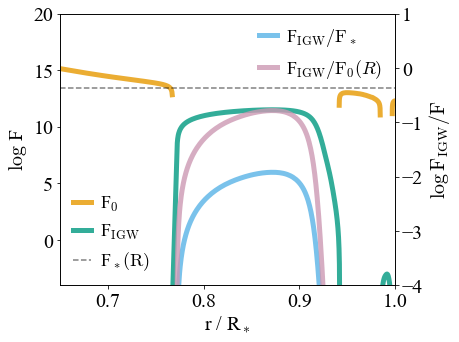

In [357]:
# Calculate average omega in FeCZ
omega_c =  np.mean(omega[minT:maxT])

# Calculate F0
# Be careful: omega is an angular frequency. So to compare to the brunt you have to transform to nu_c (divide by 2pi) 

N=brunt*muhz*pi2
print(N)
rho=10**mesa.logRho
F0=0.5*rho*(rsun*mesa.radius)**3.0
F0=F0*(omega_c)**2.0
F0=F0*(N**2.0 - omega_c**2.0)**0.5
#F0=F0*N
F0_surf=F0[1] # Take surface value of F0 
print(F0[1])

# Calculate Total Stellar Flux

L=mesa.photosphere_L
R=mesa.photosphere_r
F=(L*lsun)/(4*pi*(R*rsun)**2.0)

# Calculate Convective Flux
vc=10**mesa.log_conv_vel
Fc=rho*vc**3.0

# Calculate IGW Flux
mach=mesa.conv_vel_div_csound
Figw=Fc*mach
Figw_fecz= np.mean(Figw[minT:maxT])  # Take an average of Figw in the FeCZ



# Make the plot

fig, ax1 = plt.subplots()

f1 = ax1.plot(mesa.radius/mesa.radius[1],np.log10(F0),linewidth=5, alpha=0.8,label = r'F$_0$',color=ORANGE)
f2 = ax1.plot(mesa.radius/mesa.radius[1],np.log10(Figw),linewidth=5, alpha=0.8,label = r'F$_{\rm IGW}$',color=BLUE_GREEN)
f3 = ax1.axhline(y=np.log10(F), color='black', alpha=0.5,linestyle='--',label=r'F$_*({\rm R})$')

legend = plt.legend(loc='lower left',fontsize=18,ncol=1)

ax1.set_xlabel(r'r / R$_*$')
ax1.set_ylabel(r'$\log$ F')
ax1.set_xlim(0.65,1)
ax1.set_ylim(-4,20)

ax2 = ax1.twinx()
f4 = ax2.plot(mesa.radius/mesa.radius[1],np.log10(Figw/F),linewidth=5, color=SKY_BLUE,alpha=0.8,label = r'F$_{\rm IGW}/{\rm F}_*$')
f5 = ax2.plot(mesa.radius/mesa.radius[1],np.log10(Figw/F0_surf),linewidth=5, color=RED_PURPLE,alpha=0.8,label = r'F$_{\rm IGW}/{\rm F}_0(R)$')
ax2.set_ylim(-4, 1)
ax2.set_ylabel(r'$\log \, {\rm F}_{\rm IGW}/{\rm F}$')

print('(Figw_fecz/F0_surf)^0.5:', (Figw_fecz/F0_surf)**0.5)
legend2 = plt.legend(loc='upper right',fontsize=18,ncol=1)


plt.savefig(figures+"Fluxes_run_40Msun_zoom.pdf",bbox_inches='tight')


/Users/mcantiello/anaconda/lib/python3.5/site-packages/ipykernel/__main__.py:13: RuntimeWarning: divide by zero encountered in log10
/Users/mcantiello/anaconda/lib/python3.5/site-packages/ipykernel/__main__.py:14: RuntimeWarning: divide by zero encountered in log10


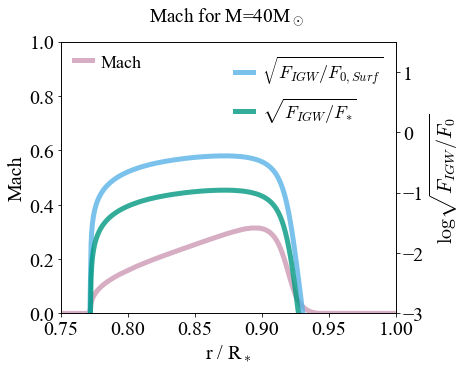

In [358]:
fig, ax1 = plt.subplots()

ax1.plot(mesa.radius/mesa.radius[1],mach,linewidth=5, color=RED_PURPLE,alpha=0.8,label = r'Mach')
ax1.set_ylabel(r'Mach')
ax1.set_xlabel(r'r / R$_*$')
ax1.set_xlim(0.65,1)
ax1.set_ylim(0,1)
legend1 = plt.legend(loc='upper left',fontsize=18,ncol=1)

ax2=ax1.twinx()


ax2.plot(mesa.radius/mesa.radius[1],np.log10((Figw/F0_surf)**0.5),linewidth=5, color=SKY_BLUE,alpha=0.8,label = r'$\sqrt{F_{IGW}/F_{0,Surf}}$')
ax2.plot(mesa.radius/mesa.radius[1],np.log10((Figw/F)**0.5),linewidth=5, color=BLUE_GREEN,alpha=0.8,label = r'$\sqrt{F_{IGW}/F_{*}}$')


legend2 = plt.legend(loc='upper right',fontsize=18,ncol=1)

ax2.set_xlim(0.75,1)
ax2.set_ylim(-3,1.5)
ax2.set_ylabel(r'$\log \sqrt{F_{IGW}/F_0}$')


#plt.ylabel(r'$\log \sqrt{F_{IGW}/F_0}$')
plt.title(r'Mach for M=40M$_\odot$ ') #X$_c$=0.68
plt.savefig(figures+"Fluxes_mach_40Msun.pdf",bbox_inches='tight')


1 d(p) = 0.011574074074074 mHz
tau ~ 0.5...5 days -> vu = 1/(2 pi tau) = 1/ (6.28* 24*3600*x) =  
def days_muhz(days,muhz): nu(d) = 0.000001843005426/d = 1.843005426/d 
So 0.5...5 d^-1 -> 3.6... 0.17  muHz 





## Lets's check when waves become non-linear
$k_r = \frac{\sqrt{\ell(\ell +1)} N}{\omega \,r} $

Waves become non-linear when the radial displacement $\xi_r$ is large enough ($\xi_r k_r \ge 1$):

$\xi_r k_r =  \frac{\sqrt{\ell(\ell +1)} N}{\omega \,r} * [ 2 F_{IGW} \sqrt{\ell(\ell+1)}/ r /(\rho \omega^2 \sqrt{N^2-\omega^2}) ]^{1/2} \sim 1$

$\xi_r k_r = [ 2 F_{IGW} N^2 (\ell(\ell+1))^{3/2} /(\rho \omega^4 \sqrt{N^2-\omega^2}) r^3 ]^{1/2} \sim 1$

$\xi_r k_r = [ 2 F_{IGW} N (\ell(\ell+1))^{3/2} / \rho \omega^4  r^3 ]^{1/2} \sim 1$


[3.27505017e+01 3.27504213e+01 3.27502432e+01 ... 1.65419534e-02
 1.31292771e-02 1.04206765e-02]


/Users/mcantiello/anaconda/lib/python3.5/site-packages/ipykernel/__main__.py:20: RuntimeWarning: invalid value encountered in sqrt


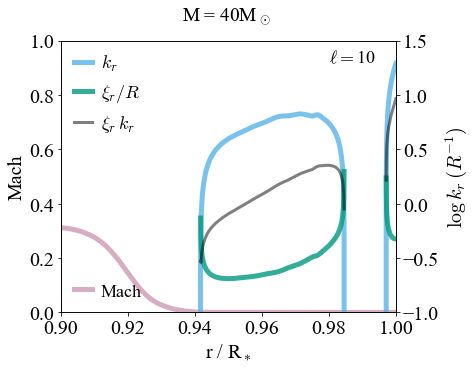

In [379]:
fig, ax1 = plt.subplots()
ell=10
R = mesa.radius
ax1.plot(R/R[1],mach,linewidth=5, color=RED_PURPLE,alpha=0.8,label = r'Mach')
ax1.set_ylabel(r'Mach')
ax1.set_xlabel(r'r / R$_*$')
ax1.set_xlim(0.9,1)
ax1.set_ylim(0,1)
legend1 = plt.legend(loc='lower left',fontsize=18,ncol=1)

ax2=ax1.twinx()
print(mesa.radius)
# Calculate radial wavenumber 
kr = k_r(ell,brunt*muhz*pi2,omega_c,R)
kh = k_h(ell,R)

ax2.plot(R/R[1],np.log10(kr),linewidth=5, color=SKY_BLUE,alpha=0.8,label = r'$k_r$')
#ax2.plot(R/R[1],kh,linewidth=3, color=ORANGE,alpha=0.8,label = r'$k_h$')
#ax2.plot(mesa.radius/mesa.radius[1],np.log10((Figw/F)**0.5),linewidth=5, color=BLUE_GREEN,alpha=0.8,label = r'$\sqrt{F_{IGW}/F_{*}}$')


xir= xi_r(ell,brunt*muhz*pi2,omega_c,R*rsun, rho, Figw_fecz)

#ax2.plot(mesa.radius/mesa.radius[1],np.log10(kr*xir),linewidth=5, color=BLUE_GREEN,alpha=0.8,label = r'$\xi_r \, k_r$')
ax2.plot(R/R[1],np.log10(xir/(R*rsun)),linewidth=5, color=BLUE_GREEN,alpha=0.8,label = r'$\xi_r/ R $')
ax2.plot(R/R[1],np.log10(kr*xir/(R*rsun)),linewidth=3, color=BLACK,alpha=0.5,label = r'$\xi_r \, k_r$')
legend2 = plt.legend(loc='upper left',fontsize=18,ncol=1)

#ax2.set_xlim(0.75,1)
ax2.set_ylim(-1,1.5)
ax2.set_ylabel(r'$\log \, k_r \, (R^{-1})$')
ax2.annotate('$\ell = $'+str(ell),(0.98,1.3), fontsize=18)

#plt.ylabel(r'$\log \sqrt{F_{IGW}/F_0}$')
plt.title(r'M = 40M$_\odot$ ') #X$_c$=0.68
plt.savefig(figures+"Fluxes_mach_40Msun.pdf",bbox_inches='tight')


[3.27505017e+01 3.27504213e+01 3.27502432e+01 ... 1.65419534e-02
 1.31292771e-02 1.04206765e-02]


/Users/mcantiello/anaconda/lib/python3.5/site-packages/ipykernel/__main__.py:20: RuntimeWarning: invalid value encountered in sqrt


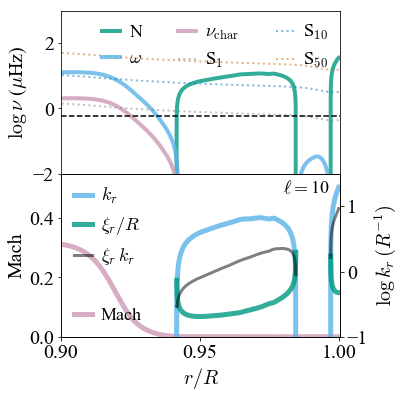

In [381]:
plt.rcParams['figure.figsize'] = (5,6)
xylim=[0.9,1.0]
lw=3
alpha = 0.8
gs1 = gridspec.GridSpec(2, 1,height_ratios=[1,1])
# No space between plots, e.g.: gs1.update(left=0.1, right=0.9, wspace=0.00,hspace=0.00)
gs1.update(wspace=0.00,hspace=0.00)

# Assign axis and remove xticks from top plot
ax1 = plt.subplot(gs1[0,0])
ax2 = plt.subplot(gs1[1,0])
#ax3 = plt.subplot(gs1[2,0])
ax1.set_xticks([])

# PROPOAGATION DIAGRAM

ax1.plot(R/R[1],np.log10(brunt),linewidth=4, alpha=0.8,label = r'N',color=BLUE_GREEN)

ax1.plot(R/R[1],np.log10(omega/muhz),linewidth=4, alpha=0.8,label = r'$\omega$',color=SKY_BLUE)
ax1.plot(R/R[1],np.log10(nu_char/muhz),linewidth=4, alpha=0.8,label = r'$\nu_{\rm char}$',color=RED_PURPLE)

ax1.plot(R/R[1],np.log10(lamb1),linewidth=2, ls=':', alpha=0.5,label = r'S$_1$',color='gray')
ax1.plot(R/R[1],np.log10(lamb10),linewidth=2, ls=':',alpha=0.5,label = r'S$_{10}$',color=BLUE)
ax1.plot(R/R[1],np.log10(lamb50),linewidth=2, ls=':',alpha=0.5,label = r'S$_{50}$',color=VERMILLION)
#plt.plot(mesa.radius/mesa.radius[1],np.log10(lamb30),linewidth=2, alpha=0.8,label = r'  S$_{30}$')
#plt.plot(mesa.radius/mesa.radius[1],np.log10(lamb300),linewidth=2, alpha=0.8,label = r'S$_{\ell = 300}$')

ax1.axhline(y=np.log10(omega_c/(pi2*muhz)), color=BLACK, linestyle='--')

legend = ax1.legend(loc='upper right',fontsize=18,ncol=3)


# Kr and Non Linearity

ax2.plot(R/R[1],mach,linewidth=5, color=RED_PURPLE,alpha=0.8,label = r'Mach')
ax2.set_ylabel(r'Mach')
ax2.set_xlabel(r'$r / R$')
ax2.set_xlim(0.9,1.0005)
ax2.set_ylim(0,1)
legend1 = ax2.legend(loc='lower left',fontsize=18,ncol=1)

ax2b=ax2.twinx()
print(mesa.radius)
# Calculate radial wavenumber 
kr = k_r(ell,brunt*muhz*pi2,omega_c,R)
kh = k_h(ell,R)


ax2b.plot(R/R[1],np.log10(kr),linewidth=5, color=SKY_BLUE,alpha=0.8,label = r'$k_r$')
#ax2.plot(R/R[1],kh,linewidth=3, color=ORANGE,alpha=0.8,label = r'$k_h$')
#ax2.plot(mesa.radius/mesa.radius[1],np.log10((Figw/F)**0.5),linewidth=5, color=BLUE_GREEN,alpha=0.8,label = r'$\sqrt{F_{IGW}/F_{*}}$')


xir= xi_r(ell,brunt*muhz*pi2,omega_c,R*rsun, rho, Figw_fecz)

#ax2.plot(mesa.radius/mesa.radius[1],np.log10(kr*xir),linewidth=5, color=BLUE_GREEN,alpha=0.8,label = r'$\xi_r \, k_r$')
ax2b.plot(R/R[1],np.log10(xir/(R*rsun)),linewidth=5, color=BLUE_GREEN,alpha=0.8,label = r'$\xi_r/ R $')
ax2b.plot(R/R[1],np.log10(kr*xir/(R*rsun)),linewidth=3, color=BLACK,alpha=0.5,label = r'$\xi_r \, k_r$')
legend2 = ax2b.legend(loc='upper left',fontsize=18,ncol=1)

ax1.set_ylim(-2,3)
ax1.set_xlim(0.9,1.0005)
ax2.set_ylim(0,0.55)
ax2b.set_ylim(-1,1.5)
ax2b.set_ylabel(r'$\log \, k_r \, (R^{-1})$')
#ax2.xlabel(r'r / R$_*$')
ax1.set_ylabel(r'$\log\, \nu$ ($\mu$Hz)')
ax2b.annotate('$\ell = $'+str(ell),(0.98,1.2), fontsize=18)
plt.savefig(figures+"Propagation_kr_40Msun.pdf",bbox_inches='tight')
plt.rcParams['figure.figsize'] = (6,5)

[3.27505017e+01 3.27504213e+01 3.27502432e+01 ... 1.65419534e-02
 1.31292771e-02 1.04206765e-02]


/Users/mcantiello/anaconda/lib/python3.5/site-packages/ipykernel/__main__.py:20: RuntimeWarning: invalid value encountered in sqrt


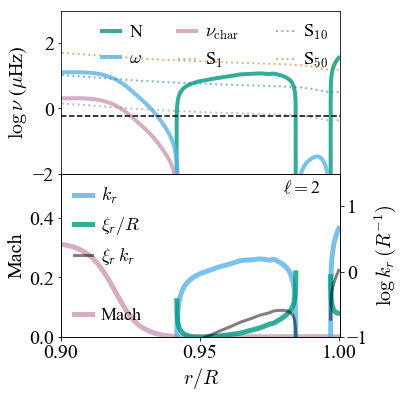

In [385]:
ell = 2
plt.rcParams['figure.figsize'] = (5,6)
xylim=[0.9,1.0]
lw=3
alpha = 0.8
gs1 = gridspec.GridSpec(2, 1,height_ratios=[1,1])
# No space between plots, e.g.: gs1.update(left=0.1, right=0.9, wspace=0.00,hspace=0.00)
gs1.update(wspace=0.00,hspace=0.00)

# Assign axis and remove xticks from top plot
ax1 = plt.subplot(gs1[0,0])
ax2 = plt.subplot(gs1[1,0])
#ax3 = plt.subplot(gs1[2,0])
ax1.set_xticks([])

# PROPOAGATION DIAGRAM

ax1.plot(R/R[1],np.log10(brunt),linewidth=4, alpha=0.8,label = r'N',color=BLUE_GREEN)

ax1.plot(R/R[1],np.log10(omega/muhz),linewidth=4, alpha=0.8,label = r'$\omega$',color=SKY_BLUE)
ax1.plot(R/R[1],np.log10(nu_char/muhz),linewidth=4, alpha=0.8,label = r'$\nu_{\rm char}$',color=RED_PURPLE)

ax1.plot(R/R[1],np.log10(lamb1),linewidth=2, ls=':', alpha=0.5,label = r'S$_1$',color='gray')
ax1.plot(R/R[1],np.log10(lamb10),linewidth=2, ls=':',alpha=0.5,label = r'S$_{10}$',color=BLUE)
ax1.plot(R/R[1],np.log10(lamb50),linewidth=2, ls=':',alpha=0.5,label = r'S$_{50}$',color=VERMILLION)
#plt.plot(mesa.radius/mesa.radius[1],np.log10(lamb30),linewidth=2, alpha=0.8,label = r'  S$_{30}$')
#plt.plot(mesa.radius/mesa.radius[1],np.log10(lamb300),linewidth=2, alpha=0.8,label = r'S$_{\ell = 300}$')

ax1.axhline(y=np.log10(omega_c/(pi2*muhz)), color=BLACK, linestyle='--')

legend = ax1.legend(loc='upper right',fontsize=18,ncol=3)


# Kr and Non Linearity

ax2.plot(R/R[1],mach,linewidth=5, color=RED_PURPLE,alpha=0.8,label = r'Mach')
ax2.set_ylabel(r'Mach')
ax2.set_xlabel(r'$r / R$')
ax2.set_xlim(0.9,1.0005)
ax2.set_ylim(0,1)
legend1 = ax2.legend(loc='lower left',fontsize=18,ncol=1)

ax2b=ax2.twinx()
print(mesa.radius)
# Calculate radial wavenumber 
kr = k_r(ell,brunt*muhz*pi2,omega_c,R)
kh = k_h(ell,R)


ax2b.plot(R/R[1],np.log10(kr),linewidth=5, color=SKY_BLUE,alpha=0.8,label = r'$k_r$')
#ax2.plot(R/R[1],kh,linewidth=3, color=ORANGE,alpha=0.8,label = r'$k_h$')
#ax2.plot(mesa.radius/mesa.radius[1],np.log10((Figw/F)**0.5),linewidth=5, color=BLUE_GREEN,alpha=0.8,label = r'$\sqrt{F_{IGW}/F_{*}}$')


xir= xi_r(ell,brunt*muhz*pi2,omega_c,R*rsun, rho, Figw_fecz)

#ax2.plot(mesa.radius/mesa.radius[1],np.log10(kr*xir),linewidth=5, color=BLUE_GREEN,alpha=0.8,label = r'$\xi_r \, k_r$')
ax2b.plot(R/R[1],np.log10(xir/(R*rsun)),linewidth=5, color=BLUE_GREEN,alpha=0.8,label = r'$\xi_r/ R $')
ax2b.plot(R/R[1],np.log10(kr*xir/(R*rsun)),linewidth=3, color=BLACK,alpha=0.5,label = r'$\xi_r \, k_r$')
legend2 = ax2b.legend(loc='upper left',fontsize=18,ncol=1)

ax1.set_ylim(-2,3)
ax1.set_xlim(0.9,1.0005)
ax2.set_ylim(0,0.55)
ax2b.set_ylim(-1,1.5)
ax2b.set_ylabel(r'$\log \, k_r \, (R^{-1})$')
#ax2.xlabel(r'r / R$_*$')
ax1.set_ylabel(r'$\log\, \nu$ ($\mu$Hz)')
ax2b.annotate('$\ell = $'+str(ell),(0.98,1.2), fontsize=18)
plt.savefig(figures+"Propagation_kr_40Msun_ell2.pdf",bbox_inches='tight')
plt.rcParams['figure.figsize'] = (6,5)

## Plot Dziembowski's b$_\ell$ c$_\ell$

In [302]:
# Dziembowski (1977) Asymptotic
def dziembowski_bc(ell):
    if (ell % 2 ) == 0 : # even
      cl=(-1)**(1+ell/2) 
      cl=cl* (2.0/(3.1415*ell))**0.5
      bl=cl/(ell**2.0)
    else: #odd
      cl=(-1)**((1+ell)/2) 
      cl=cl* (1.0/ell)*(2.0/(3.1415*ell))**0.5
      bl=cl/(ell**2.0)
    coefficients = (bl,cl)
    return coefficients;

In [303]:
bl,cl = dziembowski_bc(100)
print(bl,cl)
bl,cl = dziembowski_bc(101)
print(bl,cl)

-7.978963268897216e-06 -0.07978963268897216
-7.705869636030825e-08 -0.0007860757615715045


/Users/mcantiello/anaconda/lib/python3.5/site-packages/ipykernel/__main__.py:4: RuntimeWarning: invalid value encountered in log10
/Users/mcantiello/anaconda/lib/python3.5/site-packages/ipykernel/__main__.py:5: RuntimeWarning: invalid value encountered in log10


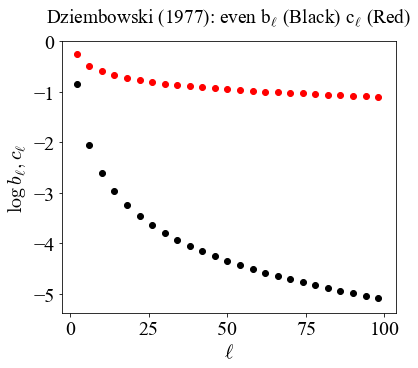

In [304]:
ell=np.arange(1,100,1)
for l in ell:
    if (l % 2 ) == 0 :
      plt.scatter(l,np.log10(dziembowski_bc(l)[0]),color='black',label=r'b$_\ell$')
      plt.scatter(l,np.log10(dziembowski_bc(l)[1]),color='red',label=r'c$_\ell$')

plt.xlabel(r'$\ell$')
plt.ylabel(r'$\log \, b_{\ell} , c_{\ell}$')
#print(dziembowski_bc(1)[0])
#plt.scatter(ell,dziembowski_bc(ell)[0])
plt.title(r'Dziembowski (1977): even b$_\ell$ (Black) c$_\ell$ (Red)') 
plt.savefig(figures+"Dziembowski_bl_cl.pdf",bbox_inches='tight')

## Visualize Spherical Harmonics

One way to understand spherical harmonics is in terms of their node lines, which are the places on the sphere where the spherical harmonics are zero. The degree l tells how many of these node lines there are in total, and the absolute value of the order |m| gives the number in longitude, so the number of node lines in latitude is l - |m|. Therefore a spherical harmonic with m = 0 has only latitudinal bands, while one with m = l has only sections like an orange. A third integer, the radial order n, tells how many nodes the oscillation has along the Sun's radius. Since only the surface of the Sun is visible to us, all the values of n are present in each spherical harmonic labelled by l and m, although only some of them will be excited to any appreciable amplitude. The total mode, then, is represented as a product of a spherical harmonic, which is a function of latitude and longitude, and another function of radius.

The total number of sectors in which the star is divided is therefore a function of $ell$ and $m$:

$N_{\rm Sectors} = (l -|m| + 1) * 2m $

So $N_{\rm cells} \propto \ell^2$, which for our FeCZ implies $\ell = 10...100$

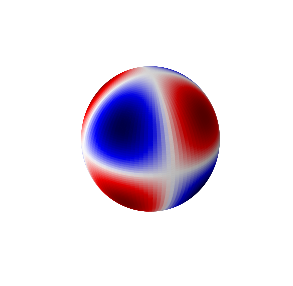

In [305]:
import matplotlib.pyplot as plt
from matplotlib import cm, colors
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
from scipy.special import sph_harm

phi = np.linspace(0, np.pi, 100)
theta = np.linspace(0, 2*np.pi, 100)
phi, theta = np.meshgrid(phi, theta)

# The Cartesian coordinates of the unit sphere
x = np.sin(phi) * np.cos(theta)
y = np.sin(phi) * np.sin(theta)
z = np.cos(phi)

m, l = 2, 3

# Calculate the spherical harmonic Y(l,m) and normalize to [0,1]
fcolors = sph_harm(m, l, theta, phi).real
fmax, fmin = fcolors.max(), fcolors.min()
fcolors = (fcolors - fmin)/(fmax - fmin)

# Set the aspect ratio to 1 so our sphere looks spherical
fig = plt.figure(figsize=plt.figaspect(1.))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(x, y, z,  rstride=1, cstride=1, facecolors=cm.seismic(fcolors))
# Turn off the axis planes
ax.set_axis_off()
plt.show()

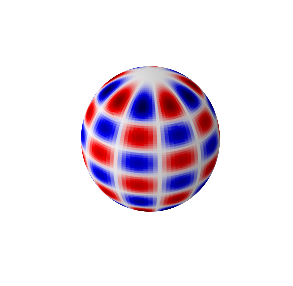

In [306]:
m, l = 5, 10

# Calculate the spherical harmonic Y(l,m) and normalize to [0,1]
fcolors = sph_harm(m, l, theta, phi).real
fmax, fmin = fcolors.max(), fcolors.min()
fcolors = (fcolors - fmin)/(fmax - fmin)

# Set the aspect ratio to 1 so our sphere looks spherical
fig = plt.figure(figsize=plt.figaspect(1.))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(x, y, z,  rstride=1, cstride=1, facecolors=cm.seismic(fcolors))
# Turn off the axis planes
ax.set_axis_off()
plt.show()

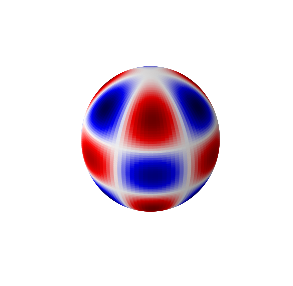

In [307]:
m, l = 3, 5

# Calculate the spherical harmonic Y(l,m) and normalize to [0,1]
fcolors = sph_harm(m, l, theta, phi).real
fmax, fmin = fcolors.max(), fcolors.min()
fcolors = (fcolors - fmin)/(fmax - fmin)

# Set the aspect ratio to 1 so our sphere looks spherical
fig = plt.figure(figsize=plt.figaspect(1.))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(x, y, z,  rstride=1, cstride=1, facecolors=cm.seismic(fcolors))
# Turn off the axis planes
ax.set_axis_off()
plt.show()